In [ ]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the paths to the datasets
data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_results(data_path):
    # Read the transformed CSV file
    df = pd.read_csv(data_path).reset_index(drop=True)
    #df.drop_duplicates()
    df['datasets'] = df['datasets'].str.strip()
    df['features'] = df['features'].str.strip()

    # Ensure the data types are consistent
    df['datasets'] = df['datasets'].astype(str)
    df['features'] = df['features'].astype(str)

    # Drop any remaining duplicates
    df = df.drop_duplicates(subset=['datasets', 'features', 'model'])

    # List of classifiers and metrics
    classifiers = ['knn', 'xgboost', 'random_forest', 'lasso']
    metrics = ['mape', 'rmse', 'ndcg_score', 'pairwise_accuracy_score', 'smape']

    # Create a grid for each classifier and metric
    for metric in metrics:
        if metric in ['mape', 'rmse', 'smape']:
            color_map = sns.cm.rocket_r
        else:
            color_map = sns.cm.rocket
        for clf in classifiers:
            # Pivot the data to get features on x-axis and datasets on y-axis
            pivot_table_rmse = df[df['model'] == clf].pivot(index='datasets', columns='features', values=metric)
            pivot_table_baseline = df[df['model'] == clf].pivot(index='datasets', columns='features', values=f'baseline_mean_{metric}')
            baseline_column = pivot_table_baseline.iloc[:, 0]

            # Determine the color scale limits
            vmin = min(pivot_table_rmse.min().min(), pivot_table_baseline.min().min())
            vmax = max(pivot_table_rmse.max().max(), pivot_table_baseline.max().max())

            # Create subplots
            fig, axes = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, figsize=(25,8))

            # Heatmap for RMSE
            sns.heatmap(pivot_table_rmse, annot=True, fmt=".2f",  ax=axes[0], cmap=color_map)
            axes[0].set_title(f'{clf} - {metric}')
            axes[0].set_xlabel('Features')
            axes[0].set_ylabel('Datasets')

            # Heatmap for Baseline Mean RMSE
            sns.heatmap(baseline_column.to_frame(), annot=True, fmt=".2f", vmin=vmin, vmax=vmax, ax=axes[1], cmap=color_map)
            axes[1].set_title(f'{clf} - Baseline Mean {metric}')
            axes[1].set_xlabel('Baseline')
            axes[1].set_ylabel('Datasets')

            # Show the plots
            plt.show()

In [ ]:
visualize_results('../../../results/comparison/all_features_new_smiles_e123.csv')

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def visualize_results_vol2(data_path):
    # Read the transformed CSV file
    sns.set(font_scale=1)
    df = pd.read_csv(data_path).reset_index(drop=True)
    #df.drop_duplicates()
    df['datasets'] = df['datasets'].str.strip()
    df['features'] = df['features'].str.strip()

    # Ensure the data types are consistent
    df['datasets'] = df['datasets'].astype(str)
    df['features'] = df['features'].astype(str)

    datasets = df['datasets'].unique().tolist()

    # Drop any remaining duplicates
    df = df.drop_duplicates(subset=['datasets', 'features', 'model'])

    # List of classifiers and metrics
    classifiers = ['knn', 'xgboost', 'random_forest', 'lasso']
    metrics = ['smape', 'rmse', 'ndcg_score', 'pairwise_accuracy_score']
    metric_mapping = {'smape': 'SMAPE', 'rmse': 'RMSE', 'ndcg_score': 'NDCG', 'pairwise_accuracy_score': 'Pairwise Accuracy'}

    # Create a grid for each classifier and metric
    for metric in metrics:
        if metric in ['mape', 'rmse', 'smape']:
            color_map = sns.color_palette("crest_r", as_cmap=True)#sns.cm.crest_r
        else:
            color_map = sns.color_palette("crest", as_cmap=True)#sns.cm.crest
        for data in datasets:
            plt.tight_layout()
            # Pivot the data to get features on x-axis and datasets on y-axis
            df = df[df['features'] != 'fp_maccs_count']
            df = df.replace({'knn': 'KNN', 'xgboost': 'XGB', 'random_forest': 'RF', 'lasso': 'Lasso'})
            df = df.replace({'fp_maccs': 'MACCS FP',
                             'fp_ecfp': 'ECFP',
                             'fp_estate': 'EState FP',
                             'fp_layered': 'Layered FP',
                             #'additive_groups': 'Additive groups',
                             'fp_functional_groups': 'Functional Groups FP',
                             'fp_topological': 'Topological FP',
                            #'additive_groups_custom': 'Custom + Additive groups',
                            #'additive_groups_dft': 'DFT + Additive groups',
                            'custom': 'Custom',
                            'custom_dft': 'Custom + DFT',
                            'custom_fp_ecfp': 'Custom + ECFP',
                            'custom_fp_estate': 'Custom + EState FP',
                            'custom_fp_functional_groups': 'Custom + Functional Groups FP',
                            'custom_fp_layered': 'Custom + Layered FP',
                            'custom_fp_maccs': 'Custom + MACCS FP',
                            'custom_fp_topological': 'Custom + Topological FP',
                            # 'dft': 'DFT',
                            # 'dft_fp_ecfp': 'DFT + ECFP',
                            # 'dft_fp_estate': 'DFT + EState FP',
                            # 'dft_fp_functional_groups': 'DFT + Functional Groups FP',
                            # 'dft_fp_layered': 'DFT + Layered FP',
                            # 'dft_fp_maccs': 'DFT + MACCS FP',
                            # 'dft_fp_topological': 'DFT + Topological FP',
                            'fp_estate_fp_maccs': 'EState + MACCS FP',
                             })
            print({'fp_maccs': 'MACCS FP',
                             'fp_ecfp': 'ECFP',
                             'fp_estate': 'EState FP',
                             'fp_layered': 'Layered FP',
                             'additive_groups': 'Additive groups',
                             'fp_functional_groups': 'Functional Groups FP',
                             'fp_topological': 'Topological FP',
                            'additive_groups_custom': 'Custom + Additive groups',
                            'additive_groups_dft': 'DFT + Additive groups',
                            'custom': 'Custom',
                            'custom_dft': 'Custom + DFT',
                            'custom_fp_ecfp': 'Custom + ECFP',
                            'custom_fp_estate': 'Custom + EState FP',
                            'custom_fp_functional_groups': 'Custom + Functional Groups FP',
                            'custom_fp_layered': 'Custom + Layered FP',
                            'custom_fp_maccs': 'Custom + MACCS FP',
                            'custom_fp_topological': 'Custom + Topological FP',
                            'dft': 'DFT',
                            'dft_fp_ecfp': 'DFT + ECFP',
                            'dft_fp_estate': 'DFT + EState FP',
                            'dft_fp_functional_groups': 'DFT + Functional Groups FP',
                            'dft_fp_layered': 'DFT + Layered FP',
                            'dft_fp_maccs': 'DFT + MACCS FP',
                            'dft_fp_topological': 'DFT + Topological FP',
                            'fp_estate_fp_maccs': 'EState + MACCS FP',
                             }.values())
            pivot_table_rmse = df[df['datasets'] == data].pivot(index='features', columns='model', values=metric)
            # print(pivot_table_rmse.index)
            # print(pivot_table_rmse.loc[['Custom + DFT']])
            pivot_table_rmse = pivot_table_rmse.loc[['Custom',
                                                     # 'Custom + Additive groups',
                                                     # 'Custom + DFT',
                                                     'Custom + ECFP',
                                                     'Custom + EState FP',
                                                     'Custom + MACCS FP',
                                                     'Custom + Functional Groups FP',
                                                     'Custom + Layered FP',
                                                     'Custom + Topological FP',
                                                     # 'DFT',
                                                     # 'DFT + Additive groups',
                                                     # 'DFT + ECFP',
                                                     # 'DFT + EState FP',
                                                     # 'DFT + MACCS FP',
                                                     # 'DFT + Functional Groups FP',
                                                     # 'DFT + Layered FP',
                                                     # 'DFT + Topological FP',
                                                     # 'Additive groups',
                                                     'ECFP',
                                                     'EState FP',
                                                     'MACCS FP',
                                                     'EState + MACCS FP',
                                                     'Layered FP',
                                                     'Functional Groups FP',
                                                     'Topological FP', ]]

            #print(pivot_table_rmse.index)
            pivot_table_baseline = df[df['datasets'] == data].pivot(index='features', columns='model', values=f'baseline_mean_{metric}')
            baseline_column = pivot_table_baseline.iloc[:, 0]

            # Determine the color scale limits
            vmin = min(pivot_table_rmse.min().min(), pivot_table_baseline.min().min())
            vmax = max(pivot_table_rmse.max().max(), pivot_table_baseline.max().max())

            # Create subplots
            #fig, axes = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, figsize=(25,8))
            fig, ax = plt.subplots(1, 1, figsize=(4, 6.5))

            # Heatmap for RMSE
            sns.heatmap(pivot_table_rmse, annot=True, fmt=".2f", cmap=color_map, linewidths=0, ax=ax, cbar=False)
            #plt.xticks(rotation=90)
            # axes[0].set_title(f'{metric}')
            # axes[0].set_xlabel('Models')
            # axes[0].set_ylabel('Features')
            ax.set_title(f'{metric_mapping[metric]}')
            ax.set_xlabel('Models')
            ax.set_ylabel('Features')
            #
            # # Heatmap for Baseline Mean RMSE
            # sns.heatmap(baseline_column.to_frame(), annot=True, fmt=".2f", vmin=vmin, vmax=vmax, ax=axes[1], cmap=color_map)
            # axes[1].set_title(f'{data} - Baseline Mean {metric}')
            # axes[1].set_xlabel('Models')
            # axes[1].set_ylabel('Baseline')

            # Show the plots
            plt.savefig('plot.png', bbox_inches='tight', dpi=300)
            plt.show()

dict_values(['MACCS FP', 'ECFP', 'EState FP', 'Layered FP', 'Additive groups', 'Functional Groups FP', 'Topological FP', 'Custom + Additive groups', 'DFT + Additive groups', 'Custom', 'Custom + DFT', 'Custom + ECFP', 'Custom + EState FP', 'Custom + Functional Groups FP', 'Custom + Layered FP', 'Custom + MACCS FP', 'Custom + Topological FP', 'DFT', 'DFT + ECFP', 'DFT + EState FP', 'DFT + Functional Groups FP', 'DFT + Layered FP', 'DFT + MACCS FP', 'DFT + Topological FP', 'EState + MACCS FP'])


<Figure size 640x480 with 0 Axes>

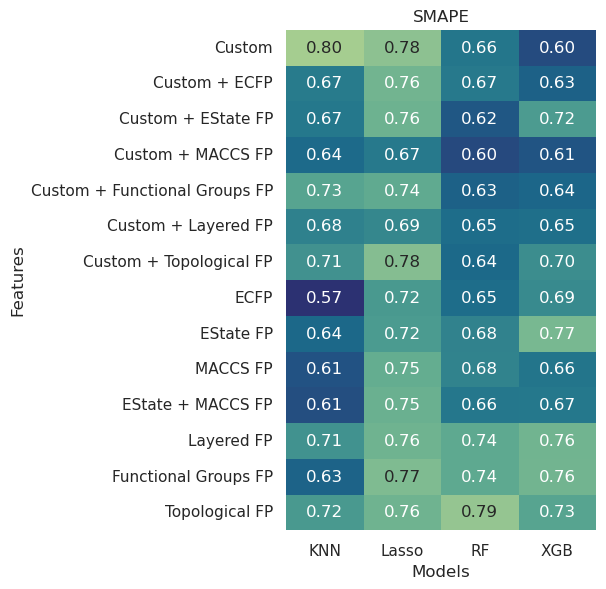

dict_values(['MACCS FP', 'ECFP', 'EState FP', 'Layered FP', 'Additive groups', 'Functional Groups FP', 'Topological FP', 'Custom + Additive groups', 'DFT + Additive groups', 'Custom', 'Custom + DFT', 'Custom + ECFP', 'Custom + EState FP', 'Custom + Functional Groups FP', 'Custom + Layered FP', 'Custom + MACCS FP', 'Custom + Topological FP', 'DFT', 'DFT + ECFP', 'DFT + EState FP', 'DFT + Functional Groups FP', 'DFT + Layered FP', 'DFT + MACCS FP', 'DFT + Topological FP', 'EState + MACCS FP'])


<Figure size 640x480 with 0 Axes>

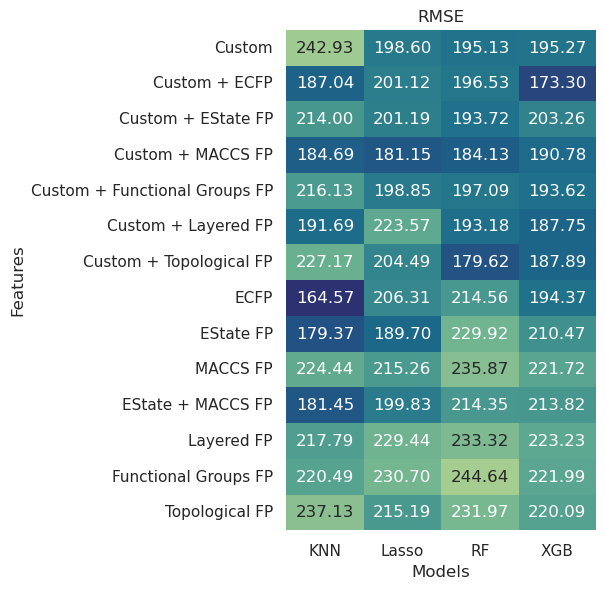

dict_values(['MACCS FP', 'ECFP', 'EState FP', 'Layered FP', 'Additive groups', 'Functional Groups FP', 'Topological FP', 'Custom + Additive groups', 'DFT + Additive groups', 'Custom', 'Custom + DFT', 'Custom + ECFP', 'Custom + EState FP', 'Custom + Functional Groups FP', 'Custom + Layered FP', 'Custom + MACCS FP', 'Custom + Topological FP', 'DFT', 'DFT + ECFP', 'DFT + EState FP', 'DFT + Functional Groups FP', 'DFT + Layered FP', 'DFT + MACCS FP', 'DFT + Topological FP', 'EState + MACCS FP'])


<Figure size 640x480 with 0 Axes>

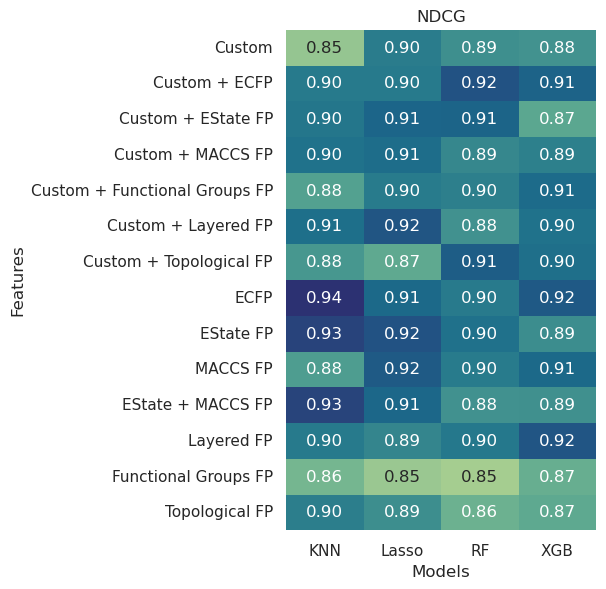

dict_values(['MACCS FP', 'ECFP', 'EState FP', 'Layered FP', 'Additive groups', 'Functional Groups FP', 'Topological FP', 'Custom + Additive groups', 'DFT + Additive groups', 'Custom', 'Custom + DFT', 'Custom + ECFP', 'Custom + EState FP', 'Custom + Functional Groups FP', 'Custom + Layered FP', 'Custom + MACCS FP', 'Custom + Topological FP', 'DFT', 'DFT + ECFP', 'DFT + EState FP', 'DFT + Functional Groups FP', 'DFT + Layered FP', 'DFT + MACCS FP', 'DFT + Topological FP', 'EState + MACCS FP'])


<Figure size 640x480 with 0 Axes>

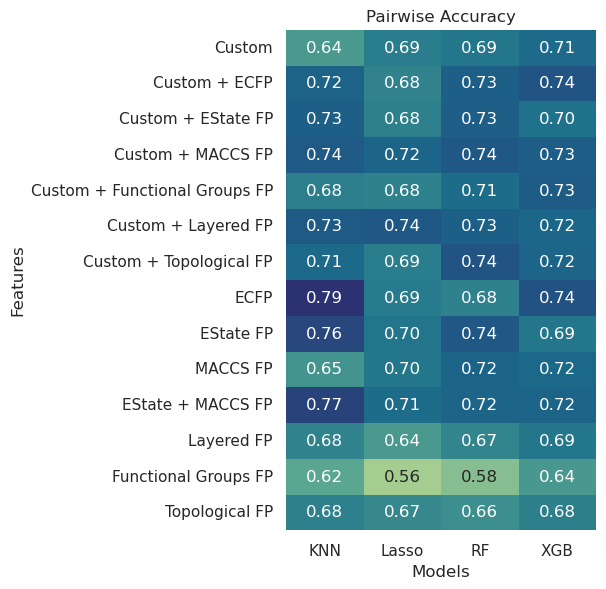

In [7]:
visualize_results_vol2('../../../results/comparison/all_features_new_smiles_e123.csv')

In [ ]:
visualize_results_vol2('../../../results/comparison/all_datasets_all_combined_all_combos_smape_10splits_5bins_tuned.csv')

In [ ]:
visualize_results_vol2('../../../results/comparison/all_datasets_all_combined_all_combos_smape_6bins.csv')

In [ ]:
visualize_results_vol2('../../../results/comparison/all_datasets_all_combined_all_combos_smape.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_maccs_count_custom.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_all_combined_all_combos_oversampling_smoter.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_all_combined_all_combos_no_expert3.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_all_combined_all_combos.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_oversampling_smoter_custom_maccs_dft.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_oversampling_bins_custom_maccs_dft.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_all_features_sorted.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_maccs_custom_selected.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_maccs_custom_symmetry.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_maccs_custom_ps.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_macss_custom_flatness.csv')

In [ ]:
visualize_results('../../../results/comparison/all_datasets_maccs_custom_flat_symmetry.csv')

Observations:
- generally the best results are obtained for random forest with expert1 and expert2 datasets (training) and MACCS fingerprints (this combo is good for most of the regressors)
- additive groups: bad results for all regressors and datasets
- experts3 dataset: bad results for all regressors and features (probably time to remove outliers or sth)
- honorable mentions: estate fingerprints + custom; expert1 + shu + saad
- for some reason layered fingerprint achieves great results for pairwise acc and ndcg with knn, but for everything else it's bad
- MACCS for the win
- expert3: not great, quite horrible

In [ ]:
dir_save = '../../../data/old/processed_selected_custom_features_restricted'
dir_now = '../../../data/old/processed_selected_custom_features'
features = ['smiles', 'capacity_max', 'flatness', 'symmetry']
import os
import pandas as pd
os.makedirs(dir_save, exist_ok=True)

for path in os.listdir(dir_now):
    print(path)
    df = pd.read_csv(os.path.join(dir_now, path))
    df = df[features]
    print(df.head())
    df.to_csv(os.path.join(dir_save, path), index=False)